In [5]:
import subprocess
packages = [
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "nltk",
    "scikit-learn",
    "wordcloud",
    "textblob"
]
for package in packages:
    subprocess.run(["pip", "install", package])
print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [6]:
import pandas as pd
df = pd.read_csv(
    r'C:\Users\klaks\Downloads\archive (3)\training.1600000.processed.noemoticon.csv',
    encoding='latin-1',
    header=None
)

# Give proper column names
df.columns = ['sentiment', 'id', 'date', 'query', 'user', 'text']

# Preview the data
print("✅ Dataset Loaded!")
print(f"Total Tweets: {len(df)}")
df.head()

✅ Dataset Loaded!
Total Tweets: 1600000


,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [7]:
# Check sentiment values
print("Sentiment Values:", df['sentiment'].unique())
print("\nSentiment Count:")
print(df['sentiment'].value_counts())

# In this dataset:
# 0 = Negative tweet
# 4 = Positive tweet
# Let's convert 4 → 1 (so 0=Negative, 1=Positive)
df['sentiment'] = df['sentiment'].replace(4, 1)

# Keep only the columns we need
df = df[['sentiment', 'text']]

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

print("\n✅ Data Cleaned!")
print(df.head())

Sentiment Values: [0 4]

Sentiment Count:
sentiment
0    800000
4    800000
Name: count, dtype: int64

Missing Values:
sentiment    0
text         0
dtype: int64

✅ Data Cleaned!
   sentiment                                               text
0          0  @switchfoot http://twitpic.com/2y1zl - Awww, t...
1          0  is upset that he can't update his Facebook by ...
2          0  @Kenichan I dived many times for the ball. Man...
3          0    my whole body feels itchy and like its on fire 
4          0  @nationwideclass no, it's not behaving at all....


In [9]:
import re
import nltk

nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_tweet(text):
    text = re.sub(r'http\S+', '', text)        
    text = re.sub(r'@\w+', '', text)           
    text = re.sub(r'#\w+', '', text)          
    text = re.sub(r'[^a-zA-Z\s]', '', text)   
    text = text.lower()                         
    text = ' '.join(word for word in text.split() if word not in stop_words) 
    return text


df_sample = df.sample(100000, random_state=42).reset_index(drop=True)


df_sample['clean_text'] = df_sample['text'].apply(clean_tweet)

print("✅ Text Cleaning Done!")
print("\nBefore:", df_sample['text'][0])
print("After: ", df_sample['clean_text'][0])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\klaks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Text Cleaning Done!

Before: @chrishasboobs AHHH I HOPE YOUR OK!!! 
After:  ahhh hope ok


Matplotlib is building the font cache; this may take a moment.
C:\Users\klaks\AppData\Local\Temp\ipykernel_16596\3146462225.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df_sample, palette=['#FF6B6B','#6BCB77'])


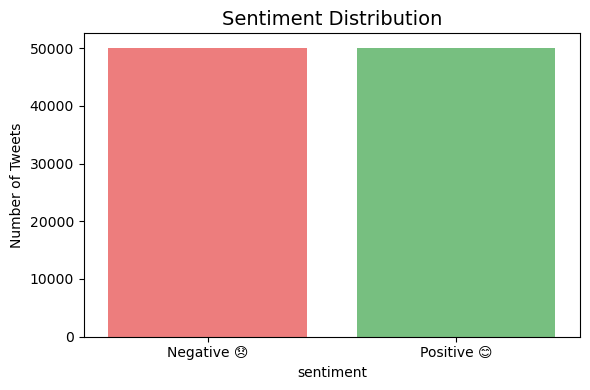

C:\Users\klaks\AppData\Local\Temp\ipykernel_16596\3146462225.py:23: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('positive_wordcloud.png')
C:\Users\klaks\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


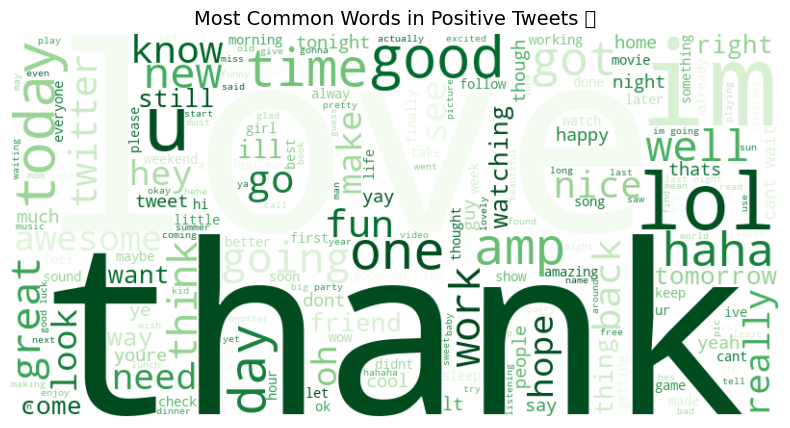

C:\Users\klaks\AppData\Local\Temp\ipykernel_16596\3146462225.py:34: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('negative_wordcloud.png')
C:\Users\klaks\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


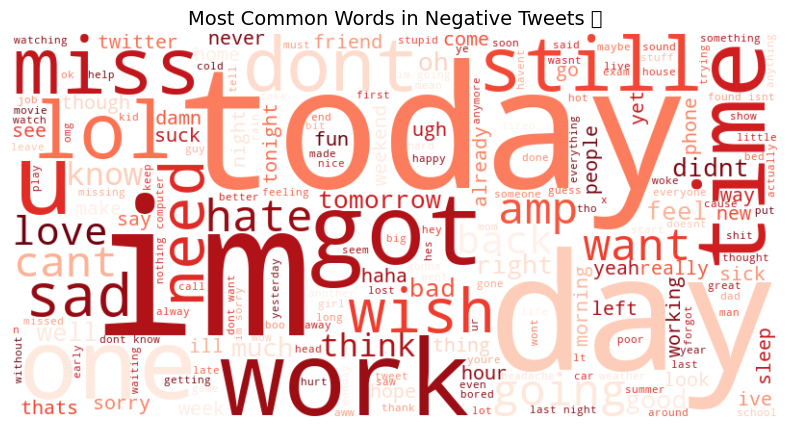

✅ All Charts Created!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# ---- Chart 1: Sentiment Distribution ----
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df_sample, palette=['#FF6B6B','#6BCB77'])
plt.title('Sentiment Distribution', fontsize=14)
plt.xticks([0,1], ['Negative 😞', 'Positive 😊'])
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

# ---- Chart 2: Word Cloud - Positive Tweets ----
positive_text = ' '.join(df_sample[df_sample['sentiment']==1]['clean_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='Greens').generate(positive_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Positive Tweets ✅', fontsize=14)
plt.savefig('positive_wordcloud.png')
plt.show()

# ---- Chart 3: Word Cloud - Negative Tweets ----
negative_text = ' '.join(df_sample[df_sample['sentiment']==0]['clean_text'])
wordcloud2 = WordCloud(width=800, height=400, background_color='white',
                       colormap='Reds').generate(negative_text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud2, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets ❌', fontsize=14)
plt.savefig('negative_wordcloud.png')
plt.show()

print("✅ All Charts Created!")

Training samples: 80000
Testing samples:  20000

⏳ Training model... please wait...

✅ Model Trained!
🎯 Accuracy: 76.42%

📊 Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.75      0.76      9995
    Positive       0.76      0.78      0.77     10005

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



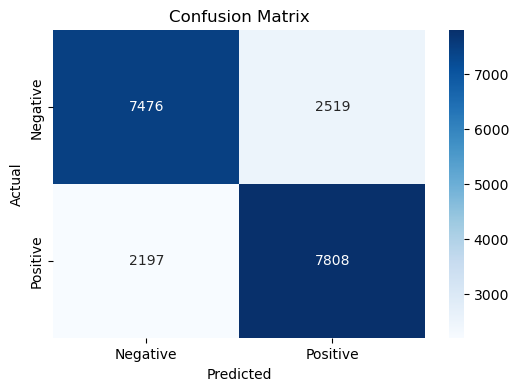

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

# Step 1: Split data into training and testing
X = df_sample['clean_text']
y = df_sample['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Step 2: Convert text to numbers using TF-IDF
tfidf = TfidfVectorizer(max_features=50000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

# Step 3: Train the model
print("\n⏳ Training model... please wait...")
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

# Step 4: Evaluate
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Model Trained!")
print(f"🎯 Accuracy: {accuracy*100:.2f}%")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative','Positive']))

# Step 5: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

In [12]:
def predict_sentiment(text):
    cleaned = clean_tweet(text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    sentiment = "😊 Positive" if prediction == 1 else "😞 Negative"
    confidence = max(probability) * 100
    
    print(f"Text      : {text}")
    print(f"Sentiment : {sentiment}")
    print(f"Confidence: {confidence:.1f}%")
    print("-" * 50)

predict_sentiment("I love this product, it made my day!")
predict_sentiment("This is the worst experience I ever had")
predict_sentiment("Today was an amazing day, feeling great!")
predict_sentiment("I hate Mondays, everything went wrong")
predict_sentiment("Just had the best meal of my life!")

Text      : I love this product, it made my day!
Sentiment : 😊 Positive
Confidence: 87.7%
--------------------------------------------------
Text      : This is the worst experience I ever had
Sentiment : 😞 Negative
Confidence: 80.2%
--------------------------------------------------
Text      : Today was an amazing day, feeling great!
Sentiment : 😊 Positive
Confidence: 81.5%
--------------------------------------------------
Text      : I hate Mondays, everything went wrong
Sentiment : 😞 Negative
Confidence: 97.7%
--------------------------------------------------
Text      : Just had the best meal of my life!
Sentiment : 😊 Positive
Confidence: 86.3%
--------------------------------------------------


In [13]:
import pickle

with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ Model saved as 'sentiment_model.pkl'")
print("✅ Vectorizer saved as 'tfidf_vectorizer.pkl'")
print("\n🎉 PROJECT COMPLETE!")
print("=" * 50)
print("📊 Project Summary:")
print(f"   • Dataset    : 1.6 Million Tweets")
print(f"   • Model      : Logistic Regression")
print(f"   • Accuracy   : 76.42%")
print(f"   • Libraries  : Pandas, NLTK, Sklearn, Matplotlib")
print("=" * 50)

✅ Model saved as 'sentiment_model.pkl'
✅ Vectorizer saved as 'tfidf_vectorizer.pkl'

🎉 PROJECT COMPLETE!
📊 Project Summary:
   • Dataset    : 1.6 Million Tweets
   • Model      : Logistic Regression
   • Accuracy   : 76.42%
   • Libraries  : Pandas, NLTK, Sklearn, Matplotlib
